# 2D Molecular Dynamics — Morse and EAM

### Markus J. Buehler, MIT

An interactive 2D MD code with **real-time visualisation** and **live parameter editing**.

**What you can do at the control panel below:**

* Choose between two interaction models:
  * **Morse** — $V(r) = D_e [1 - e^{-a(r - r_e)}]^2$, a textbook two-parameter bond potential.
  * **Embedded-Atom Method (EAM)** — Finnis–Sinclair form $E_i = -C\sqrt{\rho_i} + \tfrac{1}{2}\sum_j \phi(r_{ij})$ with $\rho(r) = B e^{-\beta r}$ and $\phi(r) = A e^{-\alpha r}$. This is a *many-body* model — cohesion depends on local density, not just pair distances.
* Press **Start** to launch; **Stop** to pause; **Reset** to rebuild the system (needed when you change lattice size, BCs, or initial $T$); **Replay** to scrub through the last few hundred recorded frames.
* While the simulation is running, **edit potential parameters, thermostat, target temperature, or `dt` — the change takes effect immediately**, without restarting.
* Colour atoms by KE, PE, speed, or virial-trace stress.

Reduced units throughout ($k_B = 1$, $m = 1$). The figure shows the current configuration plus a sliding-window history of $T(t)$, $E(t)$, and $P(t)$.

In [1]:
import asyncio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import ipywidgets as widgets
from ipywidgets import (IntSlider, FloatSlider, Dropdown, Button,
                        Output, VBox, HBox, Layout, HTML)
from IPython.display import display, clear_output

np.random.seed(0)
print('numpy', np.__version__, ' |  matplotlib', mpl.__version__, ' |  ipywidgets', widgets.__version__)

numpy 2.1.3  |  matplotlib 3.10.8  |  ipywidgets 8.1.5


## 1. The two pair interactions

**Morse potential.**
$$V_A(r) = D_e \bigl[1 - e^{-a(r - r_e)}\bigr]^2, \qquad \frac{dV}{dr} = 2 a D_e (1 - e^{-a(r-r_e)}) e^{-a(r-r_e)}.$$

This "squared" form (call it $V_A$) is a perfect square, so $V_A \ge 0$ everywhere. The minimum sits *at* zero, $V_A(r_e) = 0$, and the asymptote is $V_A(\infty) = D_e$ — the dissociation energy $D_e$ is the climb from the well bottom out to free atoms. An equivalent form, common in chemistry and matching the natural EAM convention below, shifts the zero of energy to "isolated atoms":
$$V_B(r) \;=\; V_A(r) - D_e, \qquad V_B(\infty) = 0, \quad V_B(r_e) = -D_e.$$

$V_B$ has *negative* energy in the bound state (cohesion). The two forms differ only by an additive constant, so $-dV/dr$ — and therefore the **forces, pressures, temperatures, trajectories, RDF, MSD — everything dynamical — is identical**. Only the absolute energy offset moves. The MD code in this notebook uses $V_A$ internally (textbook form, simpler expression); the cohesion plot on the right uses $V_B$ so the Morse and EAM curves share the natural zero-of-energy.

**Embedded-Atom Method (Finnis–Sinclair flavour).**
$$E_\text{tot} = \sum_i \Bigl[\, F(\rho_i) + \tfrac{1}{2} \sum_{j \ne i} \phi(r_{ij}) \Bigr], \quad \rho_i = \sum_{j \ne i} \rho(r_{ij}),$$
with $F(\rho) = -C\sqrt{\rho}$, $\rho(r) = B e^{-\beta r}$, $\phi(r) = A e^{-\alpha r}$.

EAM is **not pairwise**: the cohesive contribution $F(\rho_i)$ depends on the *sum* of pair densities at atom $i$, which gives metallic-like coordination dependence. Because both $\rho(r)$ and $\phi(r)$ are exponential decays that vanish at large $r$, **EAM is automatically on the cohesive convention**: $E_i \to 0$ for an isolated atom, $E_i < 0$ for a bound configuration. No offset to correct.

The force on atom $i$ acquires an extra term beyond the pair force:
$$\vec F_i = -\sum_{j \ne i} \Bigl[\, \phi'(r_{ij}) + \bigl( F'(\rho_i) + F'(\rho_j) \bigr) \rho'(r_{ij}) \,\Bigr]\frac{\vec r_i - \vec r_j}{r_{ij}}.$$

Below: **left**, the Morse pair potential $V_A(r)$ for a few values of the width parameter $a$ — shows how stiffness around the equilibrium controls the well shape. **Right**, the per-atom cohesive energy on a triangular lattice ($z = 6$ NN approximation) — Morse is plotted in the cohesive form $V_B$ so it shares the natural zero-of-energy with EAM and well depths are directly comparable.

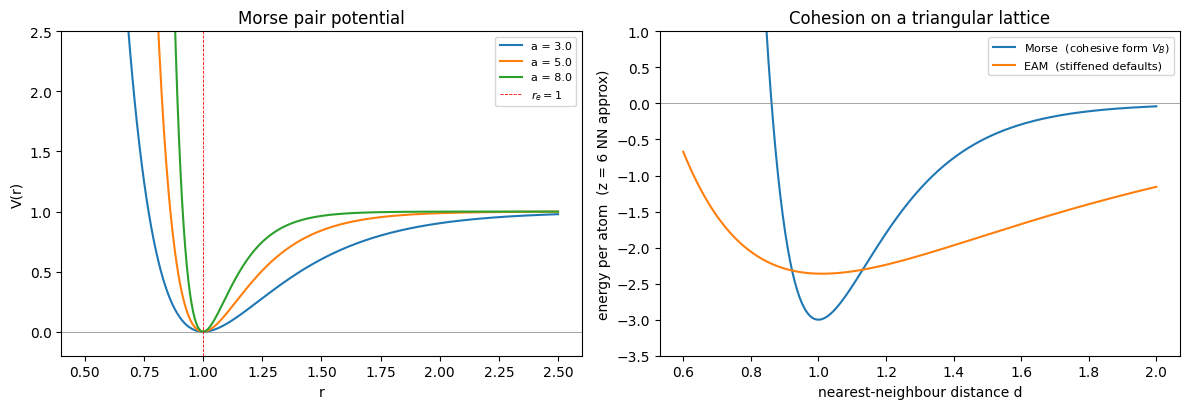

In [2]:
def morse_V(r, De=1.0, a=5.0, re=1.0):
    """Textbook 'squared' Morse form V_A. V_A(r_e)=0, V_A(inf)=D_e.
    This is what the MD code below uses internally."""
    e = np.exp(-a * (r - re))
    return De * (1.0 - e) ** 2

def morse_V_cohesive(r, De=1.0, a=5.0, re=1.0):
    """Cohesive Morse form V_B = V_A - D_e. V_B(inf)=0, V_B(r_e)=-D_e.
    Same forces (additive constant disappears under d/dr); differs only
    by a global energy offset. Used only for the cohesion-comparison plot."""
    return morse_V(r, De, a, re) - De

def morse_dVdr(r, De=1.0, a=5.0, re=1.0):
    e = np.exp(-a * (r - re))
    return 2.0 * a * De * (1.0 - e) * e

def eam_per_atom_energy_NN(d, A=15.0, alpha=4.0, B=0.5, beta=2.0, C=5.0, z=6):
    """NN approximation: each atom has z neighbours at distance d.
    Defaults tuned so the well sits near d ~ 1 with curvature roughly an order
    of magnitude stiffer than the original (much closer to the Morse well)."""
    rho = z * B * np.exp(-beta * d)
    F_embed = -C * np.sqrt(np.maximum(rho, 1e-12))
    pair    = 0.5 * z * A * np.exp(-alpha * d)
    return F_embed + pair

def morse_per_atom_energy_NN(d, De=1.0, a=5.0, re=1.0, z=6):
    """Per-atom cohesive energy on a triangular lattice for the Morse potential,
    using the *cohesive* convention V_B so V(inf) -> 0 (isolated atoms) and the
    well has negative energy -- directly comparable to EAM."""
    return 0.5 * z * morse_V_cohesive(d, De, a, re)

r_grid = np.linspace(0.5, 2.5, 600)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left panel: Morse pair potential V_A(r) for different widths a -- shows how
# the stiffness parameter a controls the well shape. (Standard textbook form.)
for a_val in [3.0, 5.0, 8.0]:
    axes[0].plot(r_grid, morse_V(r_grid, a=a_val), label=f'a = {a_val}')
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].axvline(1.0, color='red', ls='--', lw=0.6, label='$r_e = 1$')
axes[0].set_ylim(-0.2, 2.5)
axes[0].set_xlabel('r'); axes[0].set_ylabel('V(r)')
axes[0].set_title('Morse pair potential')
axes[0].legend(fontsize=8)

# Right panel: cohesion on triangular lattice -- Morse in cohesive form (V_B)
# so it shares the natural zero-of-energy (isolated atoms = 0) with EAM.
d_grid = np.linspace(0.6, 2.0, 400)
axes[1].plot(d_grid, morse_per_atom_energy_NN(d_grid), 'C0-',
             label='Morse  (cohesive form $V_B$)')
axes[1].plot(d_grid, eam_per_atom_energy_NN(d_grid),   'C1-',
             label='EAM  (stiffened defaults)')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylim(-3.5, 1.0)
axes[1].set_xlabel('nearest-neighbour distance d')
axes[1].set_ylabel('energy per atom  (z = 6 NN approx)')
axes[1].set_title('Cohesion on a triangular lattice')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2. Initial configuration

Atoms placed on a 2D triangular lattice with spacing $a_\text{lat}$. Velocities drawn from a Gaussian, centre-of-mass momentum zeroed, then exactly rescaled to $T_\text{init}$ ($\langle KE\rangle = N k_B T$ in 2D).

In [3]:
def make_lattice(nx, ny, a_lat=1.05):
    x = (np.arange(nx) * a_lat).astype(np.float64)
    y = (np.arange(ny) * a_lat * np.sqrt(3.0) / 2.0).astype(np.float64)
    xx, yy = np.meshgrid(x, y, indexing='xy')
    xx[1::2] += a_lat / 2.0
    pos = np.column_stack([xx.ravel(), yy.ravel()])
    Lbox = np.array([nx * a_lat, ny * a_lat * np.sqrt(3.0) / 2.0])
    return pos, Lbox

def init_velocities(N, T, mass=1.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    v = rng.normal(size=(N, 2)) * np.sqrt(T / mass)
    v -= v.mean(axis=0)
    KE = 0.5 * mass * (v ** 2).sum()
    T_actual = KE / N
    if T_actual > 0:
        v *= np.sqrt(T / T_actual)
    return v

## 3. Forces for Morse and EAM

Both routines return `(F, pe_per_atom, virial_per_atom)` with the same interface, so the simulator can dispatch on a single attribute. Boundary conditions are `'periodic'` (minimum image) or `'walls'` (no image; the integrator handles elastic reflection).

For EAM the force has the extra many-body term: each pair contributes $\phi'(r_{ij}) + (F'(\rho_i) + F'(\rho_j))\,\rho'(r_{ij})$. Per-atom energy is $E_i = -C\sqrt{\rho_i} + \tfrac12 \sum_j \phi(r_{ij})$. The virial per atom is computed the same way as for pair potentials (using the full pair force, which is correct because the EAM force is still a sum of pairwise contributions in the gradient form).

In [4]:
def _pairwise(pos, Lbox, bc):
    dx = pos[:, None, :] - pos[None, :, :]
    if bc == 'periodic':
        dx -= Lbox * np.round(dx / Lbox)
    r2 = (dx ** 2).sum(-1)
    np.fill_diagonal(r2, 1.0)
    return dx, np.sqrt(r2)

def compute_forces_morse(pos, Lbox, De, a, re, bc='periodic'):
    dx, r = _pairwise(pos, Lbox, bc)
    e = np.exp(-a * (r - re))
    V_pair = De * (1.0 - e) ** 2
    dV_dr  = 2.0 * a * De * (1.0 - e) * e
    np.fill_diagonal(V_pair, 0.0); np.fill_diagonal(dV_dr, 0.0)

    factor = -dV_dr / r
    np.fill_diagonal(factor, 0.0)
    F_ij = factor[:, :, None] * dx
    F = F_ij.sum(axis=1)

    pe_per  = 0.5 * V_pair.sum(axis=1)
    vir_per = 0.5 * (dx * F_ij).sum(axis=(1, 2))
    return F, pe_per, vir_per

def compute_forces_eam(pos, Lbox, A, alpha, B, beta, C, bc='periodic'):
    dx, r = _pairwise(pos, Lbox, bc)

    phi    =  A * np.exp(-alpha * r)
    dphi   = -alpha * A * np.exp(-alpha * r)   # dphi/dr
    rho_ij =  B * np.exp(-beta * r)
    drho   = -beta * B * np.exp(-beta * r)
    for arr in (phi, dphi, rho_ij, drho):
        np.fill_diagonal(arr, 0.0)

    rho_i   = rho_ij.sum(axis=1)
    rho_safe = np.maximum(rho_i, 1e-12)
    F_embed = -C * np.sqrt(rho_safe)
    Fprime  = -C / (2.0 * np.sqrt(rho_safe))   # F'(rho)

    combined = dphi + (Fprime[:, None] + Fprime[None, :]) * drho
    np.fill_diagonal(combined, 0.0)
    factor = -combined / r
    np.fill_diagonal(factor, 0.0)
    F_ij = factor[:, :, None] * dx
    F = F_ij.sum(axis=1)

    pe_per  = F_embed + 0.5 * phi.sum(axis=1)
    vir_per = 0.5 * (dx * F_ij).sum(axis=(1, 2))
    return F, pe_per, vir_per

## 4. `MDSimulator` — a stateful, steppable simulator

Everything that can be edited *while the simulation runs* is just an attribute (potential type, parameters, thermostat target, `dt`, …). The live UI reads widget values each iteration and writes them to the simulator before the next batch of steps.

In [5]:
class MDSimulator:
    def __init__(self, nx=8, ny=8, a_lat=1.05, bc='periodic',
                 T_init=0.03, mass=1.0, seed=0,
                 potential='Morse', potential_params=None,
                 thermostat='none', T_target=None, tau_T=1.0, dt=0.005):
        rng = np.random.default_rng(seed)
        self.pos, self.Lbox = make_lattice(nx, ny, a_lat)
        self.N   = self.pos.shape[0]
        self.vel = init_velocities(self.N, T_init, mass, rng)
        self.mass = mass
        self.bc   = bc

        self.potential        = potential
        self.potential_params = dict(potential_params) if potential_params else {}
        self.thermostat       = thermostat
        self.T_target         = T_target
        self.tau_T            = tau_T
        self.dt               = dt

        self.step_count = 0
        self.time = 0.0
        self._rescale_counter = 0
        self.F, self.pe_per, self.vir_per = self._forces()

    def _forces(self):
        if self.potential == 'Morse':
            return compute_forces_morse(self.pos, self.Lbox, bc=self.bc,
                                        **self.potential_params)
        if self.potential == 'EAM':
            return compute_forces_eam(self.pos, self.Lbox, bc=self.bc,
                                      **self.potential_params)
        raise ValueError(f'unknown potential: {self.potential}')

    def step(self):
        dt = self.dt
        self.vel += 0.5 * dt * self.F / self.mass
        self.pos += dt * self.vel
        if self.bc == 'periodic':
            self.pos -= self.Lbox * np.floor(self.pos / self.Lbox)
        else:
            below = self.pos < 0.0
            above = self.pos > self.Lbox
            self.pos = np.where(below, -self.pos, self.pos)
            self.pos = np.where(above, 2.0 * self.Lbox - self.pos, self.pos)
            self.vel = np.where(below | above, -self.vel, self.vel)
        self.F, self.pe_per, self.vir_per = self._forces()
        self.vel += 0.5 * dt * self.F / self.mass

        if self.T_target is not None and self.thermostat != 'none':
            KE = 0.5 * self.mass * (self.vel ** 2).sum()
            T_cur = max(KE / self.N, 1e-12)
            self._rescale_counter += 1
            if self.thermostat == 'rescale' and self._rescale_counter % 50 == 0:
                self.vel *= np.sqrt(self.T_target / T_cur)
            elif self.thermostat == 'berendsen':
                lam = np.sqrt(max(0.0, 1.0 + (dt / self.tau_T) * (self.T_target / T_cur - 1.0)))
                self.vel *= lam

        self.step_count += 1
        self.time += dt

    def snapshot(self):
        KE = 0.5 * self.mass * (self.vel ** 2).sum()
        Vbox = float(self.Lbox[0] * self.Lbox[1])
        return dict(
            pos=self.pos.copy(), vel=self.vel.copy(),
            pe_per=self.pe_per.copy(), vir_per=self.vir_per.copy(),
            T=KE / self.N, KE=KE, PE=float(self.pe_per.sum()),
            P=(2.0 * KE + float(self.vir_per.sum())) / (2.0 * Vbox),
            time=self.time, step=self.step_count,
            Lbox=self.Lbox.copy(), bc=self.bc,
            potential=self.potential, T_target=self.T_target,
        )

# Smoke test both potentials -- check NVE energy drift is small.
# EAM params are the new "stiffened" defaults so the lattice stays solid at low T,
# comparable to the Morse defaults.
for pot, pp in [('Morse', dict(De=1.0, a=5.0, re=1.0)),
                ('EAM',   dict(A=15.0, alpha=4.0, B=0.5, beta=2.0, C=5.0))]:
    sim = MDSimulator(nx=6, ny=6, a_lat=1.05, T_init=0.02,
                      potential=pot, potential_params=pp)
    E0 = sim.pe_per.sum() + 0.5 * (sim.vel ** 2).sum()
    for _ in range(500):
        sim.step()
    s = sim.snapshot()
    E1 = s['KE'] + s['PE']
    print(f'{pot:5s}: 500 NVE steps, E drift = {E1 - E0:+.2e},  T_final = {s["T"]:.4f}')

Morse: 500 NVE steps, E drift = +1.03e-04,  T_final = 0.0101


EAM  : 500 NVE steps, E drift = -8.79e-04,  T_final = 0.0106


## 5. Live, in-browser control panel

The most reliable real-time interface for this code is a **standalone HTML page** that runs the same physics in JavaScript and renders to `<canvas>` — no Python kernel, no Jupyter widget round-trip. Just a browser at 60 FPS.

> **➡ Open [Molecular Dynamics.html](Molecular%20Dynamics.html)** &nbsp; (double-click in Finder, or `open "Molecular Dynamics.html"` from a terminal).

The HTML page mirrors the parameters you'd expect — potential (Morse / EAM), lattice (nx, ny, $a_\text{lat}$), boundary conditions, thermostat (none / rescale / Berendsen), $T_\text{init}$, $T_\text{target}$, $\Delta t$, colour-by (KE / PE / speed / virial stress) — and updates the canvas in real time with `requestAnimationFrame`. Live edits apply on the next frame; **Reset** rebuilds the system from current slider values; **Replay** scrubs the last 400 snapshots.

The cell below is the original Python/ipywidgets version of the same panel. It works in JupyterLab, but the live animation can be unreliable in **VS Code's Jupyter** (asyncio/widget update path differs). If you don't see atoms moving in the cell below after clicking ▶ Start, fall back to the HTML page.

In [6]:
from pathlib import Path
from IPython.display import display

# Embed the standalone HTML/JS simulator as a self-contained iframe via srcdoc.
# - srcdoc isolates the iframe: no file-path resolution, no CORS, no sandbox issues.
# - JS in the iframe runs in its own browsing context, untouched by the notebook
#   front-end's widget/output rendering pipeline -- so animation is smooth (~60 fps).
# - Re-execute this cell to reset the simulation.
#
# If the HTML file isn't on disk (e.g. running on Google Colab, Binder, or any
# other remote kernel), fall back to fetching it from the GitHub repo.
HTML_URL = ('https://raw.githubusercontent.com/lamm-mit/'
            'MolecularDynamicsModules/main/Molecular%20Dynamics.html')
html_path = Path('Molecular Dynamics.html')
if not html_path.exists():
    import urllib.request
    print(f'Fetching {HTML_URL} ...', flush=True)
    urllib.request.urlretrieve(HTML_URL, str(html_path))
    print(f'Downloaded {html_path.stat().st_size / 1024:.1f} KB')

html_content = html_path.read_text()
escaped = html_content.replace('&', '&amp;').replace('"', '&quot;')

iframe_html = (
    f'<iframe srcdoc="{escaped}" '
    'width="1250" height="970" '
    'style="border:1px solid #ddd; border-radius:6px;"></iframe>'
)
# Use display(..., raw=True) so IPython doesn't lint the HTML for <iframe> tags
display({'text/html': iframe_html}, raw=True)

Live 2D MD — Morse and EAM 

 
 

 Live 2D Molecular Dynamics &mdash; Morse and EAM 
 Markus J. Buehler, MIT &mdash; click &#9654; Start to begin. Edit parameters live; press &#10227; Reset if you change nx, ny, a_lat, BC, T_init, or seed. 

 click &#9654; Start to begin 

 

 
 &#9654; Start 
 &#9632; Stop 
 &#10227; Reset 
 &#8635; Replay 
 &#10005; Traces 
 ready 
 tip: click an atom to trace it 
 

 
 Potential &amp; display (live) 
 
 potential 
 Morse EAM 
 
 
 colour by 
 
 KE (kinetic) 
 PE (potential) 
 |v| (speed) 
 virial (stress) 
 
 
 steps/frame 8 
 

 
 System (changes apply on Reset) 
 nx 8 
 ny 8 
 a_lat 1.05 
 bc periodic walls 
 T_init 0.030 
 seed 0 
 

 
 Morse parameters (live) 
 D_e 1.00 
 a (Morse) 5.00 
 r_e 1.00 
 

 
 EAM parameters (live) 
 A 15.00 
 alpha 4.00 
 B 0.50 
 beta 2.00 
 C 5.00 
 

 
 Thermal &amp; integration (live) 
 thermostat none rescale berendsen 
 T_target 0.050 
 tau_T (Ber.) 1.00 
 dt 0.005 
 box scale 1.00 
 

 

 
 
 
 
 
 
 
 
 
 



 
 
" width="1250" height="970" style="border:1px solid #ddd; border-radius:6px;">